# Phase 2 Stress-Regime Candidate Analysis

This notebook supports Milestone 7. It does **not** assume that a volatility spike is automatically a crisis. Instead, it explores which observable market-stress signals tend to coincide with future high-volatility / crisis-like episodes.

Purpose:

1. characterize high-volatility and crisis-like candidate episodes;
2. rank available stress indicators such as VIX, drawdown, selloff pressure, and volume stress;
3. test whether a transparent four-level warning ladder is defensible;
4. generate tables and plots for the final application narrative.

Guardrail: this is an interpretation/application layer. Track A metrics still evaluate the volatility forecast substrate.

In [1]:
from pathlib import Path
import os

if Path.cwd().name == 'notebooks':
    os.chdir('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qpitome_qrc.data.loaders import load_phase2_volatility_data
from qpitome_qrc.data.splits import chronological_tabular_split

out_table_dir = Path('results/tables')
out_fig_dir = Path('results/figures')
out_table_dir.mkdir(parents=True, exist_ok=True)
out_fig_dir.mkdir(parents=True, exist_ok=True)

## 1. Load data and define stress-oriented observables

We keep labels rule-based and train-calibrated. No hand-labeled crisis taxonomy is used.

In [2]:
target = 'future_rv_20d'
df = load_phase2_volatility_data()
splits = chronological_tabular_split(df)

def make_stress_features(frame):
    out = frame.copy().reset_index(drop=True)
    out['date'] = pd.to_datetime(out['date'])
    out['spy_selloff_stress'] = -out['spy_log_return']
    out['spy_oc_selloff_stress'] = -out['spy_log_oc_return']
    out['drawdown_stress'] = -out['spy_drawdown_20d'] if out['spy_drawdown_20d'].median() < 0 else out['spy_drawdown_20d']
    out['volume_stress'] = out['spy_log_volume_change'].abs()
    out['vix_level_stress'] = out['vix_close']
    out['vix_change_stress'] = out['vix_log_change'].clip(lower=0.0)
    out['vix_range_stress'] = out['vix_log_hl_range']
    out['realized_vol_stress'] = out['rv_20d']
    return out

splits = {k: make_stress_features(v) for k, v in splits.items()}
train, val, test = splits['train'], splits['val'], splits['test']
print(train.shape, val.shape, test.shape)
train[['date', target]].head()

(5459, 49) (1258, 49) (1058, 49)


,date,future_rv_20d
0,1993-04-27,0.100938
1,1993-04-28,0.109876
2,1993-04-29,0.109504
3,1993-04-30,0.110721
4,1993-05-03,0.113651


## 2. Define outcome events from future realized volatility

These are not subjective crisis labels. They are operational outcome events. The crisis-like candidate threshold is deliberately conservative.

In [3]:
thresholds = {
    'high_vol_q80': float(train[target].quantile(0.80)),
    'extreme_vol_q90': float(train[target].quantile(0.90)),
    'crisis_candidate_q95': float(train[target].quantile(0.95)),
}
thresholds

for split in [train, val, test]:
    split['future_high_vol_event_q80'] = split[target] > thresholds['high_vol_q80']
    split['future_extreme_vol_event_q90'] = split[target] > thresholds['extreme_vol_q90']
    split['future_crisis_candidate_q95'] = split[target] > thresholds['crisis_candidate_q95']

event_rates = pd.DataFrame({
    'split': ['train', 'val', 'test'],
    'q80_event_rate': [train['future_high_vol_event_q80'].mean(), val['future_high_vol_event_q80'].mean(), test['future_high_vol_event_q80'].mean()],
    'q90_event_rate': [train['future_extreme_vol_event_q90'].mean(), val['future_extreme_vol_event_q90'].mean(), test['future_extreme_vol_event_q90'].mean()],
    'q95_event_rate': [train['future_crisis_candidate_q95'].mean(), val['future_crisis_candidate_q95'].mean(), test['future_crisis_candidate_q95'].mean()],
})
event_rates

,split,q80_event_rate,q90_event_rate,q95_event_rate
0,train,0.200037,0.100018,0.050009
1,val,0.101749,0.025437,0.000000
2,test,0.250473,0.122873,0.048204


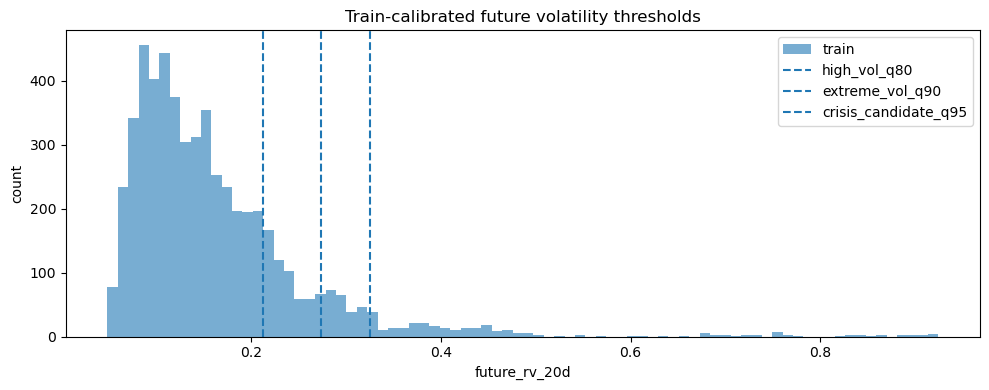

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train[target], bins=80, alpha=0.6, label='train')
for name, thr in thresholds.items():
    ax.axvline(thr, linestyle='--', label=name)
ax.set_title('Train-calibrated future volatility thresholds')
ax.set_xlabel(target)
ax.set_ylabel('count')
ax.legend()
fig.tight_layout()
fig.savefig(out_fig_dir / 'phase2_future_vol_thresholds_hist.png', dpi=180)
plt.show()

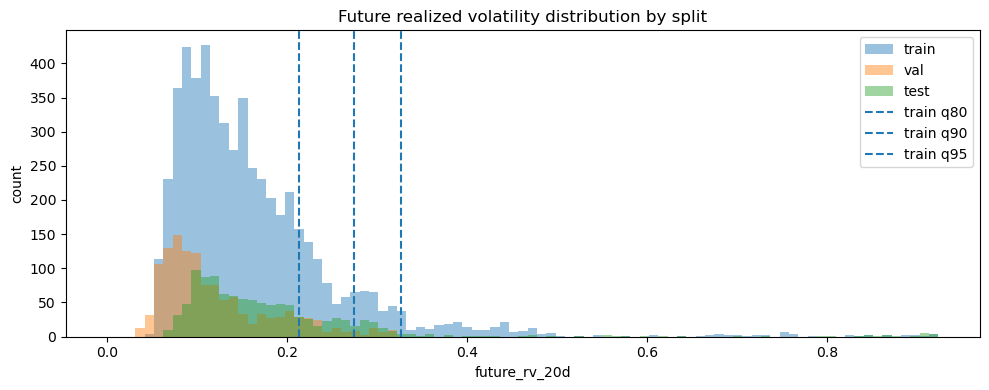

In [14]:
# Plot train/validation/test distributions of future_rv_20d
# Add this after the threshold cell.

fig, ax = plt.subplots(figsize=(10, 4))

bins = np.linspace(
    0,
    max(train[target].max(), val[target].max(), test[target].max()),
    90,
)

ax.hist(train[target], bins=bins, alpha=0.45, label="train")
ax.hist(val[target], bins=bins, alpha=0.45, label="val")
ax.hist(test[target], bins=bins, alpha=0.45, label="test")

ax.axvline(thresholds["high_vol_q80"], linestyle="--", label="train q80")
ax.axvline(thresholds["extreme_vol_q90"], linestyle="--", label="train q90")
ax.axvline(thresholds["crisis_candidate_q95"], linestyle="--", label="train q95")

ax.set_title("Future realized volatility distribution by split")
ax.set_xlabel("future_rv_20d")
ax.set_ylabel("count")
ax.legend()

fig.tight_layout()
fig.savefig(out_fig_dir / "phase2_future_vol_distribution_by_split.png", dpi=180)
plt.show()

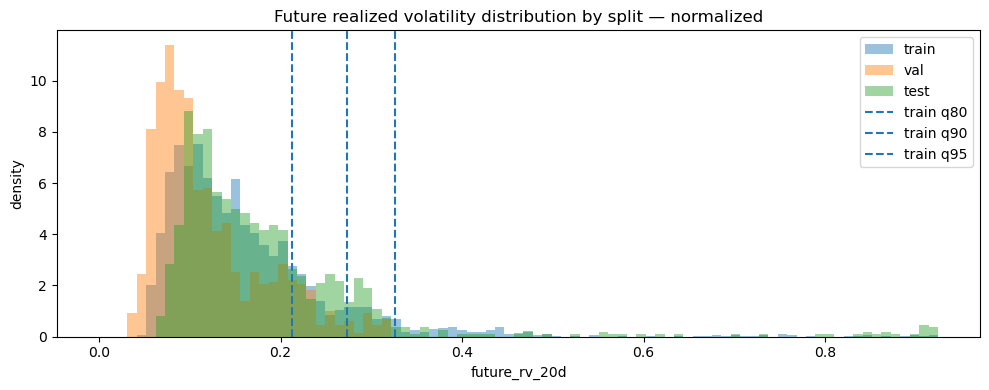

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(train[target], bins=bins, alpha=0.45, density=True, label="train")
ax.hist(val[target], bins=bins, alpha=0.45, density=True, label="val")
ax.hist(test[target], bins=bins, alpha=0.45, density=True, label="test")

ax.axvline(thresholds["high_vol_q80"], linestyle="--", label="train q80")
ax.axvline(thresholds["extreme_vol_q90"], linestyle="--", label="train q90")
ax.axvline(thresholds["crisis_candidate_q95"], linestyle="--", label="train q95")

ax.set_title("Future realized volatility distribution by split — normalized")
ax.set_xlabel("future_rv_20d")
ax.set_ylabel("density")
ax.legend()

fig.tight_layout()
fig.savefig(out_fig_dir / "phase2_future_vol_distribution_by_split_density.png", dpi=180)
plt.show()

## 3. Rank candidate stress indicators

For each signal, we test whether train-q80/q90 threshold crossings identify future high-volatility or crisis-like events. This is feature screening, not an optimized classifier.

In [5]:
candidate_features = [
    'rv_5d', 'rv_10d', 'rv_20d', 'rv_60d', 'rv_ratio_5_20', 'rv_ratio_20_60',
    'rv_slope_5_20', 'rv_slope_20_60', 'spy_abs_log_return', 'spy_squared_log_return',
    'spy_log_hl_range', 'spy_selloff_stress', 'spy_oc_selloff_stress', 'drawdown_stress',
    'spy_log_volume', 'spy_log_volume_change', 'volume_stress',
    'vix_close', 'vix_log_change', 'vix_abs_log_change', 'vix_log_hl_range',
    'vix_ma_5d', 'vix_std_5d', 'vix_ma_20d', 'vix_std_20d',
    'vix_level_stress', 'vix_change_stress', 'vix_range_stress', 'realized_vol_stress',
]
candidate_features = [c for c in candidate_features if c in train.columns]

def flag_metrics(signal_flag, event_flag):
    signal = np.asarray(signal_flag, dtype=bool)
    event = np.asarray(event_flag, dtype=bool)
    tp = int(np.sum(signal & event))
    fp = int(np.sum(signal & ~event))
    fn = int(np.sum(~signal & event))
    tn = int(np.sum(~signal & ~event))
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    return dict(tp=tp, fp=fp, fn=fn, tn=tn, precision=precision, recall=recall, f1=f1, signal_rate=float(signal.mean()))

rows = []
events = ['future_high_vol_event_q80', 'future_extreme_vol_event_q90', 'future_crisis_candidate_q95']
for feature in candidate_features:
    q80 = float(train[feature].quantile(0.80))
    q90 = float(train[feature].quantile(0.90))
    for event in events:
        for qname, thr in [('q80', q80), ('q90', q90)]:
            m = flag_metrics(test[feature] > thr, test[event])
            corr = float(np.corrcoef(test[feature], test[target])[0, 1]) if test[feature].std() > 0 else np.nan
            rows.append({
                'feature': feature, 'event': event, 'feature_threshold': qname, 'threshold_value': thr,
                'corr_with_future_rv_20d': corr, **m,
            })
ranking = pd.DataFrame(rows)
ranking.to_csv(out_table_dir / 'phase2_stress_feature_ranking_notebook.csv', index=False)
ranking.sort_values(['event', 'f1'], ascending=[True, False]).head(15)

,feature,event,feature_threshold,threshold_value,corr_with_future_rv_20d,tp,fp,fn,tn,precision,recall,f1,signal_rate
88,spy_log_volume,future_crisis_candidate_q95,q80,18.853415,0.458239,29,22,22,985,0.568627,0.568627,0.568627,0.048204
35,rv_ratio_20_60,future_crisis_candidate_q95,q90,1.251500,0.382610,43,59,8,948,0.421569,0.843137,0.562092,0.096408
89,spy_log_volume,future_crisis_candidate_q95,q90,19.232291,0.458239,19,1,32,1006,0.950000,0.372549,0.535211,0.018904
65,spy_log_hl_range,future_crisis_candidate_q95,q90,0.024566,0.559850,32,84,19,923,0.275862,0.627451,0.383234,0.109641
47,rv_slope_20_60,future_crisis_candidate_q95,q90,0.038426,0.274803,30,81,21,926,0.270270,0.588235,0.370370,0.104915
5,rv_5d,future_crisis_candidate_q95,q90,0.272075,0.590306,32,99,19,908,0.244275,0.627451,0.351648,0.123819
83,drawdown_stress,future_crisis_candidate_q95,q90,0.056535,0.561502,34,116,17,891,0.226667,0.666667,0.338308,0.141777
34,rv_ratio_20_60,future_crisis_candidate_q95,q80,1.165532,0.382610,43,169,8,838,0.202830,0.843137,0.326996,0.200378
107,vix_close,future_crisis_candidate_q95,q90,30.000000,0.565582,29,105,22,902,0.216418,0.568627,0.313514,0.126654
155,vix_level_stress,future_crisis_candidate_q95,q90,30.000000,0.565582,29,105,22,902,0.216418,0.568627,0.313514,0.126654


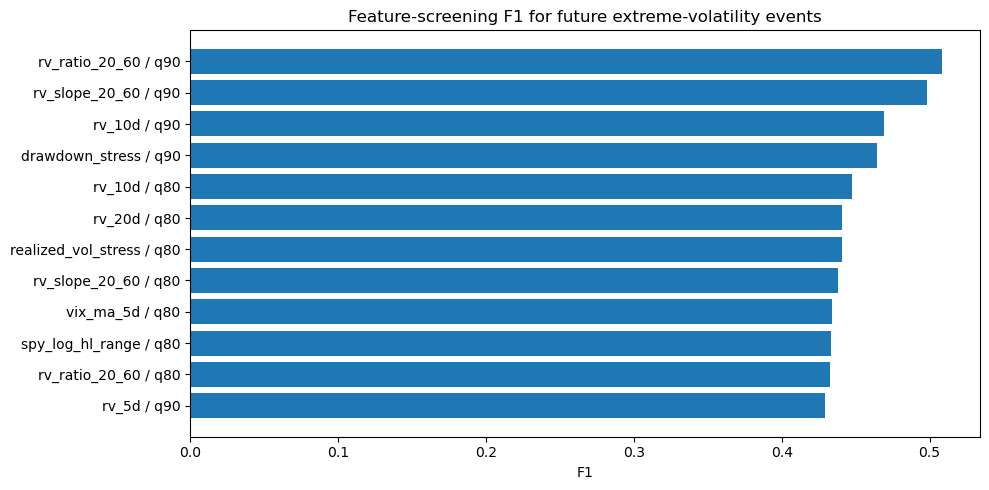

In [6]:
plot_rank = (ranking[ranking['event'] == 'future_extreme_vol_event_q90']
             .sort_values('f1', ascending=False)
             .head(12)
             .copy())
plot_rank['label'] = plot_rank['feature'] + ' / ' + plot_rank['feature_threshold']

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(plot_rank['label'][::-1], plot_rank['f1'][::-1])
ax.set_title('Feature-screening F1 for future extreme-volatility events')
ax.set_xlabel('F1')
fig.tight_layout()
fig.savefig(out_fig_dir / 'phase2_stress_feature_ranking_f1.png', dpi=180)
plt.show()

## 4. Profile top future-volatility episodes

This is the sanity check: do top future-volatility episodes look like known stress conditions across VIX, drawdown, selloff, volume, and realized-volatility state?

In [7]:
profile_cols = [
    'date', target, 'rv_20d', 'vix_close', 'vix_ma_20d', 'vix_std_20d',
    'drawdown_stress', 'spy_selloff_stress', 'spy_log_hl_range', 'volume_stress',
    'future_high_vol_event_q80', 'future_extreme_vol_event_q90', 'future_crisis_candidate_q95',
]
top_future = test.sort_values(target, ascending=False).head(30)[profile_cols]
top_future.to_csv(out_table_dir / 'phase2_top_future_volatility_profile_notebook.csv', index=False)
top_future.head(15)

,date,future_rv_20d,rv_20d,vix_close,vix_ma_20d,vix_std_20d,drawdown_stress,spy_selloff_stress,spy_log_hl_range,volume_stress,future_high_vol_event_q80,future_extreme_vol_event_q90,future_crisis_candidate_q95
39,2020-02-28,0.923201,0.257810,40.11,19.5895,8.112623,0.124372,0.004210,0.042349,0.305008,True,True,True
40,2020-03-02,0.917891,0.291344,33.42,20.3185,8.677164,0.086451,-0.042395,0.048716,0.480003,True,True,True
38,2020-02-27,0.917062,0.257633,39.16,18.3585,6.552967,0.120677,0.045951,0.046156,0.378379,True,True,True
42,2020-03-04,0.916564,0.336604,31.99,22.0580,9.610414,0.075309,-0.041174,0.031701,0.530283,True,True,True
41,2020-03-03,0.913637,0.307936,36.82,21.2610,9.402095,0.112609,0.029050,0.053234,0.229023,True,True,True
43,2020-03-05,0.912276,0.355023,39.62,23.2815,10.222796,0.106047,0.033807,0.027809,0.053754,True,True,True
44,2020-03-06,0.911821,0.359722,41.94,24.6305,10.829059,0.120825,0.016669,0.029034,0.204551,True,True,True
37,2020-02-26,0.909413,0.199445,27.56,17.2200,4.359714,0.079328,0.003685,0.023569,0.116836,True,True,True
36,2020-02-25,0.907976,0.202426,27.85,16.6560,3.618237,0.075930,0.030771,0.040615,0.306722,True,True,True
45,2020-03-09,0.895185,0.460813,54.46,26.5800,12.477295,0.189484,0.081313,0.038524,0.302423,True,True,True


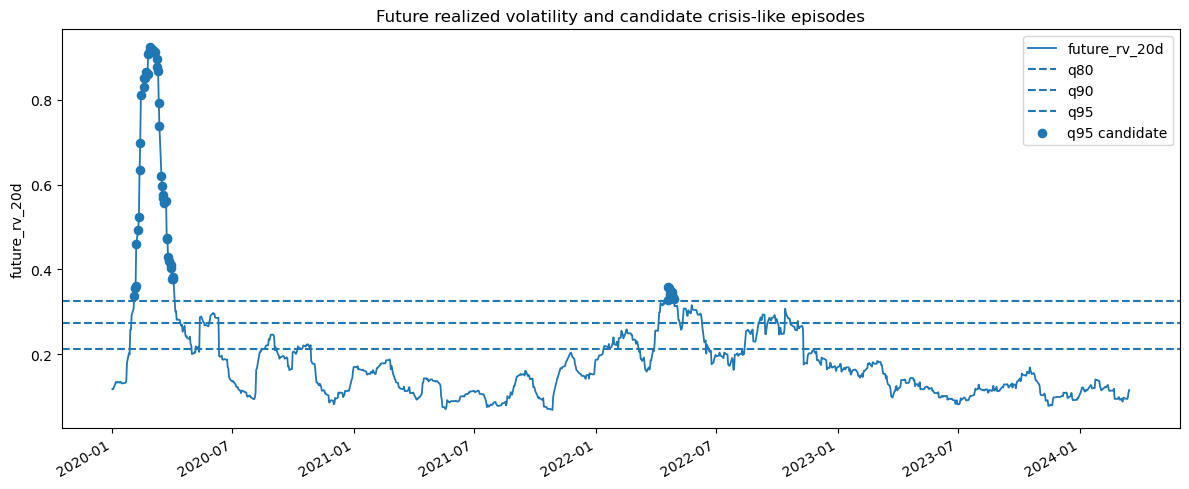

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test['date'], test[target], label='future_rv_20d', linewidth=1.3)
ax.axhline(thresholds['high_vol_q80'], linestyle='--', label='q80')
ax.axhline(thresholds['extreme_vol_q90'], linestyle='--', label='q90')
ax.axhline(thresholds['crisis_candidate_q95'], linestyle='--', label='q95')
crisis_like = test[test['future_crisis_candidate_q95']]
ax.scatter(crisis_like['date'], crisis_like[target], marker='o', s=35, label='q95 candidate')
ax.set_title('Future realized volatility and candidate crisis-like episodes')
ax.set_ylabel(target)
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(out_fig_dir / 'phase2_future_volatility_candidate_episodes.png', dpi=180)
plt.show()

## 5. Build transparent stress-score ladder

This ladder is operational: Normal → Watch → Warning → Crisis-like. It is not a claim that the market has exactly four latent regimes.

In [9]:
def q(col, p):
    return float(train[col].quantile(p))

timeline = test.copy()
timeline['flag_realized_vol'] = timeline['rv_20d'] > q('rv_20d', 0.80)
timeline['flag_vix_level'] = timeline['vix_close'] > q('vix_close', 0.80)
timeline['flag_vix_range'] = timeline['vix_log_hl_range'] > q('vix_log_hl_range', 0.80)
timeline['flag_drawdown'] = timeline['drawdown_stress'] > q('drawdown_stress', 0.80)
timeline['flag_selloff'] = timeline['spy_selloff_stress'] > q('spy_selloff_stress', 0.80)
timeline['flag_volume'] = timeline['volume_stress'] > q('volume_stress', 0.80)
timeline['flag_vol_acceleration'] = timeline['rv_slope_5_20'] > q('rv_slope_5_20', 0.80)

flag_cols = [c for c in timeline.columns if c.startswith('flag_')]
timeline['stress_score'] = timeline[flag_cols].sum(axis=1)
timeline['stress_ladder'] = pd.cut(
    timeline['stress_score'],
    bins=[-0.1, 0.5, 1.5, 2.5, len(flag_cols) + 0.5],
    labels=['normal', 'watch', 'warning', 'crisis_like'],
).astype(str)
timeline['direction_tag'] = 'neutral'
timeline.loc[timeline['spy_log_return'] > q('spy_log_return', 0.70), 'direction_tag'] = 'rally'
timeline.loc[timeline['spy_log_return'] < q('spy_log_return', 0.30), 'direction_tag'] = 'selloff'
timeline['regime_descriptor'] = timeline['stress_ladder'] + '_' + timeline['direction_tag']
timeline.to_csv(out_table_dir / 'phase2_stress_ladder_timeline_notebook.csv', index=False)
timeline[['date', target, 'stress_score', 'stress_ladder', 'direction_tag', 'regime_descriptor'] + flag_cols].head()

,date,future_rv_20d,stress_score,stress_ladder,direction_tag,regime_descriptor,flag_realized_vol,flag_vix_level,flag_vix_range,flag_drawdown,flag_selloff,flag_volume,flag_vol_acceleration
0,2020-01-02,0.117560,1,watch,rally,watch_rally,False,False,True,False,False,False,False
1,2020-01-03,0.117399,2,warning,selloff,warning_selloff,False,False,True,False,True,False,False
2,2020-01-06,0.128385,1,watch,neutral,watch_neutral,False,False,True,False,False,False,False
3,2020-01-07,0.134328,0,normal,neutral,normal_neutral,False,False,False,False,False,False,False
4,2020-01-08,0.133529,1,watch,rally,watch_rally,False,False,True,False,False,False,False


In [10]:
ladder_counts = timeline.groupby(['stress_ladder', 'direction_tag']).size().reset_index(name='n')
ladder_counts.to_csv(out_table_dir / 'phase2_stress_ladder_counts_notebook.csv', index=False)
ladder_counts

,stress_ladder,direction_tag,n
0,crisis_like,neutral,34
1,crisis_like,rally,87
2,crisis_like,selloff,177
3,normal,neutral,185
4,normal,rally,95
5,normal,selloff,35
6,warning,neutral,30
7,warning,rally,62
8,warning,selloff,77
9,watch,neutral,117


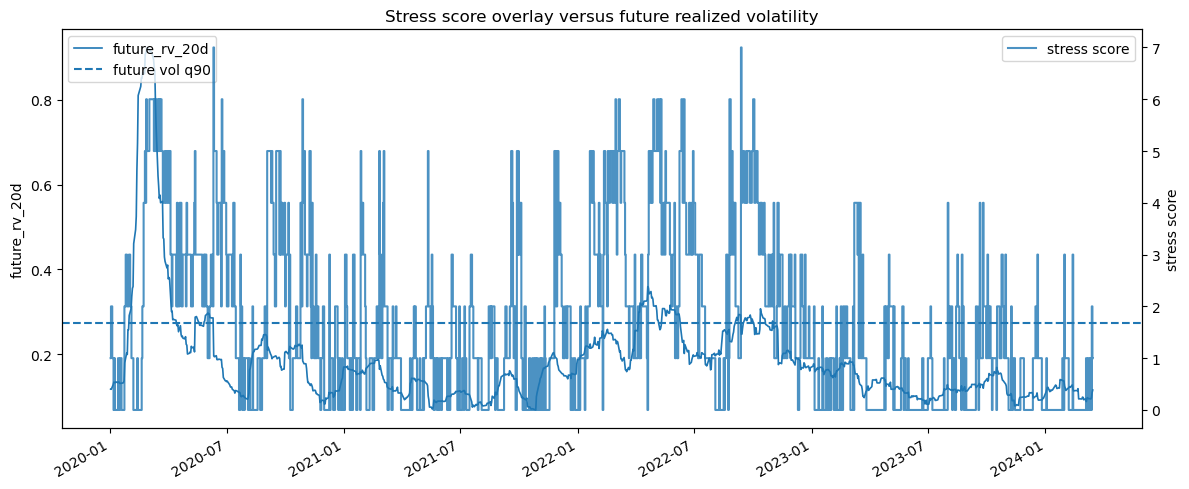

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(timeline['date'], timeline[target], label='future_rv_20d', linewidth=1.2)
ax2 = ax.twinx()
ax2.step(timeline['date'], timeline['stress_score'], where='mid', label='stress score', alpha=0.8)
ax.axhline(thresholds['extreme_vol_q90'], linestyle='--', label='future vol q90')
ax.set_title('Stress score overlay versus future realized volatility')
ax.set_ylabel(target)
ax2.set_ylabel('stress score')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(out_fig_dir / 'phase2_stress_score_overlay.png', dpi=180)
plt.show()

### 5b. Refine ladder to avoid over-labeling crisis-like regimes

In [19]:
core_cols = ["flag_realized_vol", "flag_vol_acceleration"]
confirm_cols = ["flag_vix_level", "flag_vix_range", "flag_drawdown", "flag_selloff", "flag_volume"]

timeline["core_score"] = timeline[core_cols].sum(axis=1)
timeline["confirm_score"] = timeline[confirm_cols].sum(axis=1)

timeline["stress_ladder_v2"] = "normal"

timeline.loc[
    (timeline["core_score"] >= 1) | (timeline["confirm_score"] >= 2),
    "stress_ladder_v2"
] = "watch"

timeline.loc[
    (timeline["core_score"] >= 1) & (timeline["confirm_score"] >= 2),
    "stress_ladder_v2"
] = "warning"

timeline.loc[
    (timeline["core_score"] >= 1)
    & (timeline["confirm_score"] >= 3)
    & (
        timeline["flag_drawdown"]
        | timeline["flag_selloff"]
        | timeline["flag_vix_level"]
    ),
    "stress_ladder_v2"
] = "crisis_like"

timeline["regime_descriptor_v2"] = timeline["stress_ladder_v2"] + "_" + timeline["direction_tag"]

timeline.groupby(["stress_ladder_v2", "direction_tag"]).size().reset_index(name="n")

,stress_ladder_v2,direction_tag,n
0,crisis_like,neutral,12
1,crisis_like,rally,36
2,crisis_like,selloff,113
3,normal,neutral,279
4,normal,rally,168
5,normal,selloff,82
6,warning,neutral,21
7,warning,rally,45
8,warning,selloff,37
9,watch,neutral,54


In [20]:
ladder_counts_v2 = (
    timeline
    .groupby(["stress_ladder_v2", "direction_tag"])
    .size()
    .reset_index(name="n")
)

ladder_counts_v2.to_csv(
    out_table_dir / "phase2_stress_ladder_counts_v2_notebook.csv",
    index=False,
)

ladder_counts_v2

,stress_ladder_v2,direction_tag,n
0,crisis_like,neutral,12
1,crisis_like,rally,36
2,crisis_like,selloff,113
3,normal,neutral,279
4,normal,rally,168
5,normal,selloff,82
6,warning,neutral,21
7,warning,rally,45
8,warning,selloff,37
9,watch,neutral,54


### 5c. Add persistence-filtered v3 ladder

In [25]:
# v3: persistence-filtered v2 ladder

timeline["v2_warning_or_higher_raw"] = timeline["stress_ladder_v2"].isin(
    ["warning", "crisis_like"]
)

timeline["v2_watch_or_higher_raw"] = timeline["stress_ladder_v2"].isin(
    ["watch", "warning", "crisis_like"]
)

timeline["warning_persistent_2of3"] = (
    timeline["v2_warning_or_higher_raw"].rolling(3, min_periods=1).sum() >= 2
)

timeline["watch_persistent_2of3"] = (
    timeline["v2_watch_or_higher_raw"].rolling(3, min_periods=1).sum() >= 2
)

timeline["stress_ladder_v3"] = "normal"

timeline.loc[
    timeline["watch_persistent_2of3"],
    "stress_ladder_v3"
] = "watch"

timeline.loc[
    timeline["warning_persistent_2of3"],
    "stress_ladder_v3"
] = "warning"

timeline.loc[
    timeline["stress_ladder_v2"].eq("crisis_like"),
    "stress_ladder_v3"
] = "crisis_like"

timeline["regime_descriptor_v3"] = timeline["stress_ladder_v3"] + "_" + timeline["direction_tag"]

timeline.groupby(["stress_ladder_v3", "direction_tag"]).size().reset_index(name="n")

,stress_ladder_v3,direction_tag,n
0,crisis_like,neutral,12
1,crisis_like,rally,36
2,crisis_like,selloff,113
3,normal,neutral,267
4,normal,rally,149
5,normal,selloff,126
6,warning,neutral,27
7,warning,rally,64
8,warning,selloff,26
9,watch,neutral,60


## 6. Evaluate warning thresholds

This evaluates whether the ladder is useful for future high-volatility / extreme-volatility events. It does not replace volatility forecasting metrics.

In [12]:
eval_rows = []
for thr in [1, 2, 3, 4]:
    signal = timeline['stress_score'] >= thr
    for event in events:
        eval_rows.append({'signal': f'stress_score >= {thr}', 'event': event, 'threshold': thr, **flag_metrics(signal, timeline[event])})
ladder_eval = pd.DataFrame(eval_rows).sort_values(['event', 'f1'], ascending=[True, False])
ladder_eval.to_csv(out_table_dir / 'phase2_stress_ladder_evaluation_notebook.csv', index=False)
ladder_eval

,signal,event,threshold,tp,fp,fn,tn,precision,recall,f1,signal_rate
11,stress_score >= 4,future_crisis_candidate_q95,4,35,142,16,865,0.197740,0.686275,0.307018,0.167297
8,stress_score >= 3,future_crisis_candidate_q95,3,36,262,15,745,0.120805,0.705882,0.206304,0.281664
5,stress_score >= 2,future_crisis_candidate_q95,2,37,430,14,577,0.079229,0.725490,0.142857,0.441399
2,stress_score >= 1,future_crisis_candidate_q95,1,43,700,8,307,0.057873,0.843137,0.108312,0.702268
10,stress_score >= 4,future_extreme_vol_event_q90,4,63,114,67,814,0.355932,0.484615,0.410423,0.167297
7,stress_score >= 3,future_extreme_vol_event_q90,3,87,211,43,717,0.291946,0.669231,0.406542,0.281664
4,stress_score >= 2,future_extreme_vol_event_q90,2,107,360,23,568,0.229122,0.823077,0.358459,0.441399
1,stress_score >= 1,future_extreme_vol_event_q90,1,122,621,8,307,0.164199,0.938462,0.279496,0.702268
6,stress_score >= 3,future_high_vol_event_q80,3,160,138,105,655,0.536913,0.603774,0.568384,0.281664
3,stress_score >= 2,future_high_vol_event_q80,2,208,259,57,534,0.445396,0.784906,0.568306,0.441399


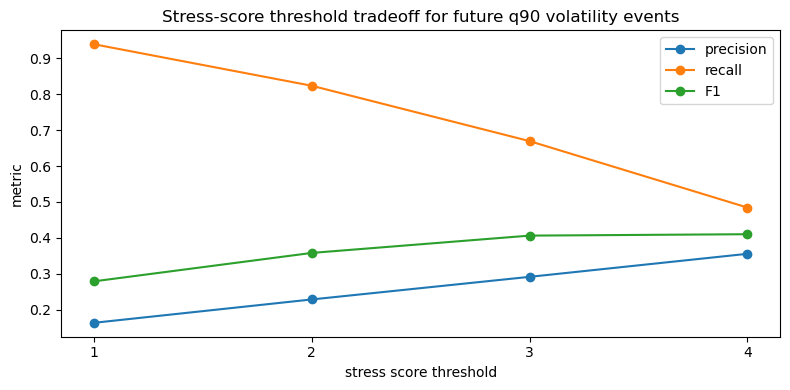

In [13]:
plot_eval = ladder_eval[ladder_eval['event'] == 'future_extreme_vol_event_q90'].copy()
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(plot_eval['threshold'], plot_eval['precision'], marker='o', label='precision')
ax.plot(plot_eval['threshold'], plot_eval['recall'], marker='o', label='recall')
ax.plot(plot_eval['threshold'], plot_eval['f1'], marker='o', label='F1')
ax.set_title('Stress-score threshold tradeoff for future q90 volatility events')
ax.set_xlabel('stress score threshold')
ax.set_ylabel('metric')
ax.set_xticks(plot_eval['threshold'])
ax.legend()
fig.tight_layout()
fig.savefig(out_fig_dir / 'phase2_stress_ladder_threshold_tradeoff.png', dpi=180)
plt.show()

In [21]:
# Evaluate v2 ladder labels directly.

v2_signal_defs = {
    "v2_watch_or_higher": timeline["stress_ladder_v2"].isin(["watch", "warning", "crisis_like"]),
    "v2_warning_or_higher": timeline["stress_ladder_v2"].isin(["warning", "crisis_like"]),
    "v2_crisis_like": timeline["stress_ladder_v2"].eq("crisis_like"),
}

v2_eval_rows = []
for signal_name, signal in v2_signal_defs.items():
    for event in events:
        row = {
            "signal": signal_name,
            "event": event,
        }
        row.update(flag_metrics(signal, timeline[event]))
        v2_eval_rows.append(row)

v2_eval = pd.DataFrame(v2_eval_rows).sort_values(
    ["event", "f1"],
    ascending=[True, False],
)

v2_eval.to_csv(
    out_table_dir / "phase2_stress_ladder_v2_evaluation_notebook.csv",
    index=False,
)

v2_eval

,signal,event,tp,fp,fn,tn,precision,recall,f1,signal_rate
8,v2_crisis_like,future_crisis_candidate_q95,35,126,16,881,0.217391,0.686275,0.330189,0.152174
5,v2_warning_or_higher,future_crisis_candidate_q95,35,229,16,778,0.132576,0.686275,0.222222,0.249527
2,v2_watch_or_higher,future_crisis_candidate_q95,40,489,11,518,0.075614,0.784314,0.137931,0.500000
4,v2_warning_or_higher,future_extreme_vol_event_q90,83,181,47,747,0.314394,0.638462,0.421320,0.249527
7,v2_crisis_like,future_extreme_vol_event_q90,61,100,69,828,0.378882,0.469231,0.419244,0.152174
1,v2_watch_or_higher,future_extreme_vol_event_q90,112,417,18,511,0.211720,0.861538,0.339909,0.500000
3,v2_warning_or_higher,future_high_vol_event_q80,150,114,115,679,0.568182,0.566038,0.567108,0.249527
0,v2_watch_or_higher,future_high_vol_event_q80,218,311,47,482,0.412098,0.822642,0.549118,0.500000
6,v2_crisis_like,future_high_vol_event_q80,101,60,164,733,0.627329,0.381132,0.474178,0.152174


## 7. Evaluate warning robustness by split

Validation is a calm-period stress test: the main failure mode is false positives.
Test is an elevated-stress-period stress test: the main failure mode is false negatives.

In [16]:
# Evaluate stress-score warning thresholds separately on validation and test.

def evaluate_split_warning(split_name, frame, thresholds=(1, 2, 3, 4)):
    rows = []
    for thr in thresholds:
        signal = frame["stress_score"] >= thr
        for event in events:
            row = {
                "split": split_name,
                "signal": f"stress_score >= {thr}",
                "threshold": thr,
                "event": event,
            }
            row.update(flag_metrics(signal, frame[event]))
            rows.append(row)
    return pd.DataFrame(rows)

# Need to build the same stress ladder for validation.
val_timeline = val.copy()

val_timeline["flag_realized_vol"] = val_timeline["rv_20d"] > q("rv_20d", 0.80)
val_timeline["flag_vix_level"] = val_timeline["vix_close"] > q("vix_close", 0.80)
val_timeline["flag_vix_range"] = val_timeline["vix_log_hl_range"] > q("vix_log_hl_range", 0.80)
val_timeline["flag_drawdown"] = val_timeline["drawdown_stress"] > q("drawdown_stress", 0.80)
val_timeline["flag_selloff"] = val_timeline["spy_selloff_stress"] > q("spy_selloff_stress", 0.80)
val_timeline["flag_volume"] = val_timeline["volume_stress"] > q("volume_stress", 0.80)
val_timeline["flag_vol_acceleration"] = val_timeline["rv_slope_5_20"] > q("rv_slope_5_20", 0.80)

val_flag_cols = [c for c in val_timeline.columns if c.startswith("flag_")]
val_timeline["stress_score"] = val_timeline[val_flag_cols].sum(axis=1)

split_ladder_eval = pd.concat(
    [
        evaluate_split_warning("val", val_timeline),
        evaluate_split_warning("test", timeline),
    ],
    ignore_index=True,
)

split_ladder_eval.to_csv(
    out_table_dir / "phase2_stress_ladder_eval_by_split_notebook.csv",
    index=False,
)

split_ladder_eval.sort_values(["event", "threshold", "split"])

,split,signal,threshold,event,tp,fp,fn,tn,precision,recall,f1,signal_rate
14,test,stress_score >= 1,1,future_crisis_candidate_q95,43,700,8,307,0.057873,0.843137,0.108312,0.702268
2,val,stress_score >= 1,1,future_crisis_candidate_q95,0,762,0,496,0.000000,0.000000,0.000000,0.605723
17,test,stress_score >= 2,2,future_crisis_candidate_q95,37,430,14,577,0.079229,0.725490,0.142857,0.441399
5,val,stress_score >= 2,2,future_crisis_candidate_q95,0,354,0,904,0.000000,0.000000,0.000000,0.281399
20,test,stress_score >= 3,3,future_crisis_candidate_q95,36,262,15,745,0.120805,0.705882,0.206304,0.281664
8,val,stress_score >= 3,3,future_crisis_candidate_q95,0,189,0,1069,0.000000,0.000000,0.000000,0.150238
23,test,stress_score >= 4,4,future_crisis_candidate_q95,35,142,16,865,0.197740,0.686275,0.307018,0.167297
11,val,stress_score >= 4,4,future_crisis_candidate_q95,0,87,0,1171,0.000000,0.000000,0.000000,0.069157
13,test,stress_score >= 1,1,future_extreme_vol_event_q90,122,621,8,307,0.164199,0.938462,0.279496,0.702268
1,val,stress_score >= 1,1,future_extreme_vol_event_q90,25,737,7,489,0.032808,0.781250,0.062972,0.605723


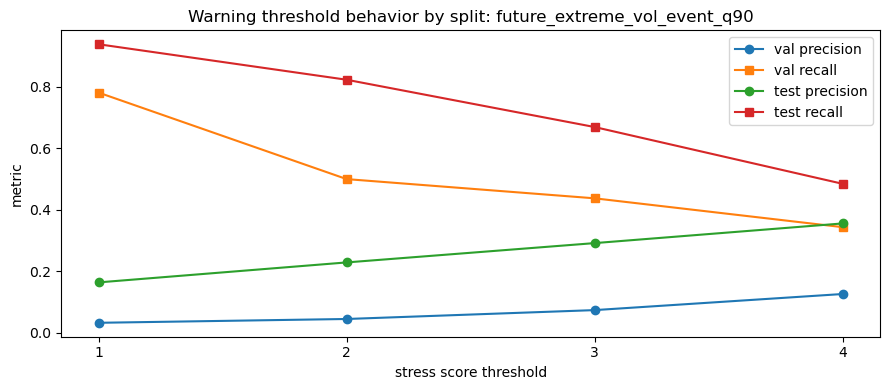

In [17]:
event_to_plot = "future_extreme_vol_event_q90"
plot_df = split_ladder_eval[split_ladder_eval["event"] == event_to_plot].copy()

fig, ax = plt.subplots(figsize=(9, 4))

for split_name in ["val", "test"]:
    part = plot_df[plot_df["split"] == split_name].sort_values("threshold")
    ax.plot(part["threshold"], part["precision"], marker="o", label=f"{split_name} precision")
    ax.plot(part["threshold"], part["recall"], marker="s", label=f"{split_name} recall")

ax.set_title(f"Warning threshold behavior by split: {event_to_plot}")
ax.set_xlabel("stress score threshold")
ax.set_ylabel("metric")
ax.set_xticks(sorted(plot_df["threshold"].unique()))
ax.legend()

fig.tight_layout()
fig.savefig(out_fig_dir / "phase2_stress_ladder_eval_by_split.png", dpi=180)
plt.show()

In [22]:
# Evaluate v2 ladder separately on validation and test.

def add_ladder_v2(frame):
    out = frame.copy()

    out["flag_realized_vol"] = out["rv_20d"] > q("rv_20d", 0.80)
    out["flag_vix_level"] = out["vix_close"] > q("vix_close", 0.80)
    out["flag_vix_range"] = out["vix_log_hl_range"] > q("vix_log_hl_range", 0.80)
    out["flag_drawdown"] = out["drawdown_stress"] > q("drawdown_stress", 0.80)
    out["flag_selloff"] = out["spy_selloff_stress"] > q("spy_selloff_stress", 0.80)
    out["flag_volume"] = out["volume_stress"] > q("volume_stress", 0.80)
    out["flag_vol_acceleration"] = out["rv_slope_5_20"] > q("rv_slope_5_20", 0.80)

    core_cols = ["flag_realized_vol", "flag_vol_acceleration"]
    confirm_cols = ["flag_vix_level", "flag_vix_range", "flag_drawdown", "flag_selloff", "flag_volume"]

    out["core_score"] = out[core_cols].sum(axis=1)
    out["confirm_score"] = out[confirm_cols].sum(axis=1)

    out["stress_ladder_v2"] = "normal"

    out.loc[
        (out["core_score"] >= 1) | (out["confirm_score"] >= 2),
        "stress_ladder_v2",
    ] = "watch"

    out.loc[
        (out["core_score"] >= 1) & (out["confirm_score"] >= 2),
        "stress_ladder_v2",
    ] = "warning"

    out.loc[
        (out["core_score"] >= 1)
        & (out["confirm_score"] >= 3)
        & (out["flag_drawdown"] | out["flag_selloff"] | out["flag_vix_level"]),
        "stress_ladder_v2",
    ] = "crisis_like"

    return out


val_v2 = add_ladder_v2(val)
test_v2 = timeline.copy()

def evaluate_v2_split(split_name, frame):
    signal_defs = {
        "v2_watch_or_higher": frame["stress_ladder_v2"].isin(["watch", "warning", "crisis_like"]),
        "v2_warning_or_higher": frame["stress_ladder_v2"].isin(["warning", "crisis_like"]),
        "v2_crisis_like": frame["stress_ladder_v2"].eq("crisis_like"),
    }

    rows = []
    for signal_name, signal in signal_defs.items():
        for event in events:
            row = {"split": split_name, "signal": signal_name, "event": event}
            row.update(flag_metrics(signal, frame[event]))
            rows.append(row)
    return pd.DataFrame(rows)

v2_by_split = pd.concat(
    [
        evaluate_v2_split("val", val_v2),
        evaluate_v2_split("test", test_v2),
    ],
    ignore_index=True,
)

v2_by_split.to_csv(
    out_table_dir / "phase2_stress_ladder_v2_eval_by_split_notebook.csv",
    index=False,
)

v2_by_split.sort_values(["event", "signal", "split"])

,split,signal,event,tp,fp,fn,tn,precision,recall,f1,signal_rate
17,test,v2_crisis_like,future_crisis_candidate_q95,35,126,16,881,0.217391,0.686275,0.330189,0.152174
8,val,v2_crisis_like,future_crisis_candidate_q95,0,74,0,1184,0.000000,0.000000,0.000000,0.058824
14,test,v2_warning_or_higher,future_crisis_candidate_q95,35,229,16,778,0.132576,0.686275,0.222222,0.249527
5,val,v2_warning_or_higher,future_crisis_candidate_q95,0,157,0,1101,0.000000,0.000000,0.000000,0.124801
11,test,v2_watch_or_higher,future_crisis_candidate_q95,40,489,11,518,0.075614,0.784314,0.137931,0.500000
2,val,v2_watch_or_higher,future_crisis_candidate_q95,0,403,0,855,0.000000,0.000000,0.000000,0.320350
16,test,v2_crisis_like,future_extreme_vol_event_q90,61,100,69,828,0.378882,0.469231,0.419244,0.152174
7,val,v2_crisis_like,future_extreme_vol_event_q90,8,66,24,1160,0.108108,0.250000,0.150943,0.058824
13,test,v2_warning_or_higher,future_extreme_vol_event_q90,83,181,47,747,0.314394,0.638462,0.421320,0.249527
4,val,v2_warning_or_higher,future_extreme_vol_event_q90,13,144,19,1082,0.082803,0.406250,0.137566,0.124801


In [23]:
counts_by_split = pd.concat(
    [
        val_v2.assign(split="val"),
        test_v2.assign(split="test"),
    ],
    ignore_index=True,
)

v2_counts_by_split = (
    counts_by_split
    .groupby(["split", "stress_ladder_v2"])
    .size()
    .reset_index(name="n")
)

v2_counts_by_split["share"] = (
    v2_counts_by_split["n"]
    / v2_counts_by_split.groupby("split")["n"].transform("sum")
)

v2_counts_by_split.to_csv(
    out_table_dir / "phase2_stress_ladder_v2_counts_by_split_notebook.csv",
    index=False,
)

v2_counts_by_split

,split,stress_ladder_v2,n,share
0,test,crisis_like,161,0.152174
1,test,normal,529,0.500000
2,test,warning,103,0.097353
3,test,watch,265,0.250473
4,val,crisis_like,74,0.058824
5,val,normal,855,0.679650
6,val,warning,83,0.065978
7,val,watch,246,0.195548


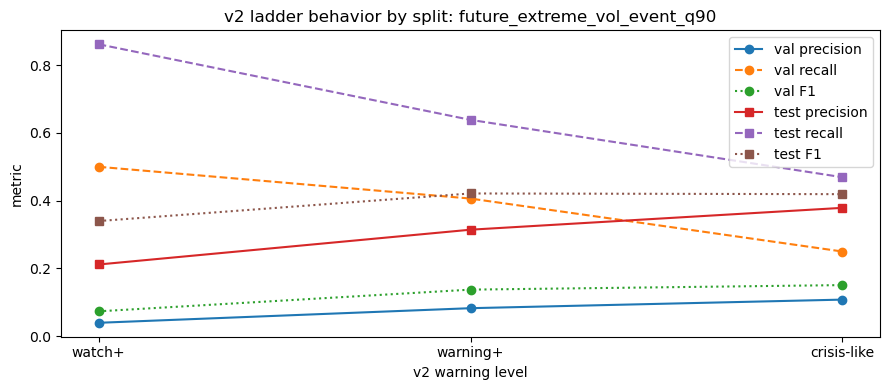

In [24]:
# Plot v2 warning performance by split for q90 future extreme-volatility events.

event_to_plot = "future_extreme_vol_event_q90"
plot_df = v2_by_split[v2_by_split["event"] == event_to_plot].copy()

# Order the v2 operating levels from broad to selective.
signal_order = ["v2_watch_or_higher", "v2_warning_or_higher", "v2_crisis_like"]
x = np.arange(len(signal_order))

fig, ax = plt.subplots(figsize=(9, 4))

for split_name, marker in [("val", "o"), ("test", "s")]:
    part = (
        plot_df[plot_df["split"] == split_name]
        .set_index("signal")
        .loc[signal_order]
        .reset_index()
    )

    ax.plot(x, part["precision"], marker=marker, label=f"{split_name} precision")
    ax.plot(x, part["recall"], marker=marker, linestyle="--", label=f"{split_name} recall")
    ax.plot(x, part["f1"], marker=marker, linestyle=":", label=f"{split_name} F1")

ax.set_title(f"v2 ladder behavior by split: {event_to_plot}")
ax.set_xlabel("v2 warning level")
ax.set_ylabel("metric")
ax.set_xticks(x)
ax.set_xticklabels(["watch+", "warning+", "crisis-like"])
ax.legend()

fig.tight_layout()
fig.savefig(out_fig_dir / "phase2_stress_ladder_v2_eval_by_split_q90.png", dpi=180)
plt.show()

### 7b. Evaluate persistence-filtered v3 ladder

In [26]:
# Evaluate v3 ladder labels directly on test.

v3_signal_defs = {
    "v3_watch_or_higher": timeline["stress_ladder_v3"].isin(
        ["watch", "warning", "crisis_like"]
    ),
    "v3_warning_or_higher": timeline["stress_ladder_v3"].isin(
        ["warning", "crisis_like"]
    ),
    "v3_crisis_like": timeline["stress_ladder_v3"].eq("crisis_like"),
}

v3_eval_rows = []

for signal_name, signal in v3_signal_defs.items():
    for event in events:
        row = {
            "signal": signal_name,
            "event": event,
        }
        row.update(flag_metrics(signal, timeline[event]))
        v3_eval_rows.append(row)

v3_eval = pd.DataFrame(v3_eval_rows).sort_values(
    ["event", "f1"],
    ascending=[True, False],
)

v3_eval.to_csv(
    out_table_dir / "phase2_stress_ladder_v3_evaluation_notebook.csv",
    index=False,
)

v3_eval

,signal,event,tp,fp,fn,tn,precision,recall,f1,signal_rate
8,v3_crisis_like,future_crisis_candidate_q95,35,126,16,881,0.217391,0.686275,0.330189,0.152174
5,v3_warning_or_higher,future_crisis_candidate_q95,35,243,16,764,0.125899,0.686275,0.212766,0.262760
2,v3_watch_or_higher,future_crisis_candidate_q95,40,476,11,531,0.077519,0.784314,0.141093,0.487713
4,v3_warning_or_higher,future_extreme_vol_event_q90,87,191,43,737,0.312950,0.669231,0.426471,0.262760
7,v3_crisis_like,future_extreme_vol_event_q90,61,100,69,828,0.378882,0.469231,0.419244,0.152174
1,v3_watch_or_higher,future_extreme_vol_event_q90,113,403,17,525,0.218992,0.869231,0.349845,0.487713
3,v3_warning_or_higher,future_high_vol_event_q80,158,120,107,673,0.568345,0.596226,0.581952,0.262760
0,v3_watch_or_higher,future_high_vol_event_q80,215,301,50,492,0.416667,0.811321,0.550576,0.487713
6,v3_crisis_like,future_high_vol_event_q80,101,60,164,733,0.627329,0.381132,0.474178,0.152174


In [27]:
# Compare v2 and v3 on the test split.

v2_eval_compare = v2_eval.copy()
v2_eval_compare["ladder"] = "v2"

v3_eval_compare = v3_eval.copy()
v3_eval_compare["ladder"] = "v3"

ladder_compare = pd.concat(
    [v2_eval_compare, v3_eval_compare],
    ignore_index=True,
)

ladder_compare = ladder_compare[
    [
        "ladder",
        "signal",
        "event",
        "precision",
        "recall",
        "f1",
        "signal_rate",
        "tp",
        "fp",
        "fn",
        "tn",
    ]
].sort_values(["event", "ladder", "f1"], ascending=[True, True, False])

ladder_compare.to_csv(
    out_table_dir / "phase2_stress_ladder_v2_vs_v3_comparison_notebook.csv",
    index=False,
)

ladder_compare

,ladder,signal,event,precision,recall,f1,signal_rate,tp,fp,fn,tn
0,v2,v2_crisis_like,future_crisis_candidate_q95,0.217391,0.686275,0.330189,0.152174,35,126,16,881
1,v2,v2_warning_or_higher,future_crisis_candidate_q95,0.132576,0.686275,0.222222,0.249527,35,229,16,778
2,v2,v2_watch_or_higher,future_crisis_candidate_q95,0.075614,0.784314,0.137931,0.500000,40,489,11,518
9,v3,v3_crisis_like,future_crisis_candidate_q95,0.217391,0.686275,0.330189,0.152174,35,126,16,881
10,v3,v3_warning_or_higher,future_crisis_candidate_q95,0.125899,0.686275,0.212766,0.262760,35,243,16,764
11,v3,v3_watch_or_higher,future_crisis_candidate_q95,0.077519,0.784314,0.141093,0.487713,40,476,11,531
3,v2,v2_warning_or_higher,future_extreme_vol_event_q90,0.314394,0.638462,0.421320,0.249527,83,181,47,747
4,v2,v2_crisis_like,future_extreme_vol_event_q90,0.378882,0.469231,0.419244,0.152174,61,100,69,828
5,v2,v2_watch_or_higher,future_extreme_vol_event_q90,0.211720,0.861538,0.339909,0.500000,112,417,18,511
12,v3,v3_warning_or_higher,future_extreme_vol_event_q90,0.312950,0.669231,0.426471,0.262760,87,191,43,737


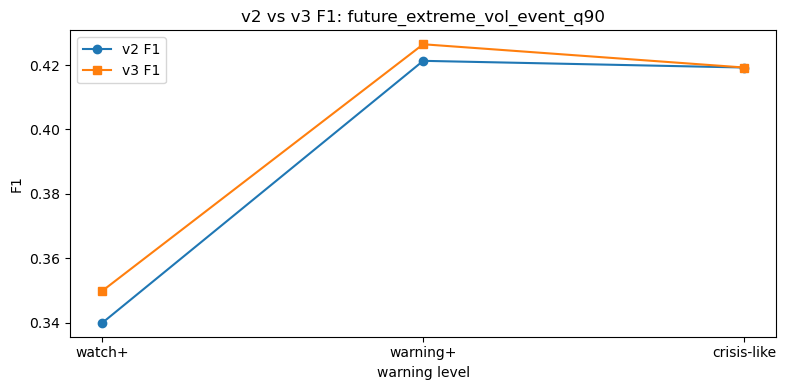

In [28]:
# Plot v2 vs v3 F1 for q90 future extreme-volatility events.

event_to_plot = "future_extreme_vol_event_q90"

plot_compare = ladder_compare[ladder_compare["event"] == event_to_plot].copy()

plot_compare["level"] = plot_compare["signal"].str.replace("v2_", "", regex=False)
plot_compare["level"] = plot_compare["level"].str.replace("v3_", "", regex=False)

level_order = ["watch_or_higher", "warning_or_higher", "crisis_like"]

fig, ax = plt.subplots(figsize=(8, 4))

for ladder_name, marker in [("v2", "o"), ("v3", "s")]:
    part = (
        plot_compare[plot_compare["ladder"] == ladder_name]
        .set_index("level")
        .loc[level_order]
        .reset_index()
    )

    ax.plot(
        range(len(level_order)),
        part["f1"],
        marker=marker,
        label=f"{ladder_name} F1",
    )

ax.set_title(f"v2 vs v3 F1: {event_to_plot}")
ax.set_xlabel("warning level")
ax.set_ylabel("F1")
ax.set_xticks(range(len(level_order)))
ax.set_xticklabels(["watch+", "warning+", "crisis-like"])
ax.legend()

fig.tight_layout()
fig.savefig(out_fig_dir / "phase2_stress_ladder_v2_vs_v3_f1_q90.png", dpi=180)
plt.show()

## 8. Interpretation checkpoint

Use this section to decide whether the four-level ladder is defensible.

Required checks:

- Do known/high-volatility episodes activate multiple stress indicators?
- Does a higher stress score improve precision while lower levels preserve recall?
- Are `crisis_like` periods mostly selloff stress, or do some occur during volatile rallies?
- Does the ladder create a useful industry-facing danger-zone sequence without pretending to discover true latent regimes?

Recommended language if the diagnostics look reasonable:

> We define an operational stress-warning ladder rather than a full market-regime taxonomy. The ladder combines future-volatility risk with observable market-stress confirmations such as VIX, drawdown, selloff pressure, and volume stress. A separate direction tag distinguishes selloff stress from volatile rallies.